In [1]:
# Cell 1 — Imports & Setup
import os
import fitz  # PyMuPDF
import chromadb
from sentence_transformers import SentenceTransformer
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Settings
PDF_FOLDER = "data/pdfs"               # Folder containing your ITR PDFs
EMBED_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
DB_ROOT = "ablation_dbs"               # Temp folder for ablation collections
TOP_K = 3

# Fixed list of 10 test questions (same for all chunk sizes)
TEST_QUESTIONS = [
    "Who is eligible to file ITR-1?",
    "What is the last date to file ITR?",
    "How is TDS on salary calculated?",
    "What is the 87A rebate?",
    "Can a non-resident file ITR-2?",
    "What are the sections under Chapter VI-A deductions?",
    "What is the penalty for late filing?",
    "How to report capital gains?",
    "What is the standard deduction for salaried employees?",
    "Is it mandatory to link PAN with Aadhaar?"
]

c:\Users\aikya\Downloads\smai a3\adv_chatbot\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Cell 2 — Load the embedding model (cached)
model = SentenceTransformer(EMBED_MODEL_NAME)
print(f"Model loaded: {EMBED_MODEL_NAME}")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 12700.30it/s]


Model loaded: sentence-transformers/all-MiniLM-L6-v2


In [3]:
# Cell 3 — PDF text extraction function
def extract_text_from_pdfs(folder):
    """Read all PDFs in folder, return a dict {filename: full_text}."""
    texts = {}
    if not os.path.isdir(folder):
        print(f"Warning: PDF folder '{folder}' not found. Using dummy text for demo.")
        # Dummy text so the notebook still runs if PDFs are missing
        texts["dummy.pdf"] = " ".join(["This is a dummy tax document about ITR filing. " * 100])
        return texts
    for fname in sorted(os.listdir(folder)):
        if fname.lower().endswith(".pdf"):
            path = os.path.join(folder, fname)
            try:
                doc = fitz.open(path)
                full = ""
                for page in doc:
                    full += page.get_text()
                doc.close()
                texts[fname] = full
                print(f"  Extracted: {fname} ({len(full)} chars)")
            except Exception as e:
                print(f"  Skipping {fname}: {e}")
    return texts

In [4]:
# Cell 3 — PDF text extraction function
def extract_text_from_pdfs(folder):
    """Read all PDFs in folder, return a dict {filename: full_text}."""
    texts = {}
    if not os.path.isdir(folder):
        print(f"Warning: PDF folder '{folder}' not found. Using dummy text for demo.")
        # Dummy text so the notebook still runs if PDFs are missing
        texts["dummy.pdf"] = " ".join(["This is a dummy tax document about ITR filing. " * 100])
        return texts
    for fname in sorted(os.listdir(folder)):
        if fname.lower().endswith(".pdf"):
            path = os.path.join(folder, fname)
            try:
                doc = fitz.open(path)
                full = ""
                for page in doc:
                    full += page.get_text()
                doc.close()
                texts[fname] = full
                print(f"  Extracted: {fname} ({len(full)} chars)")
            except Exception as e:
                print(f"  Skipping {fname}: {e}")
    return texts

In [5]:
# Cell 4 — Chunk text into overlapping pieces
def chunk_text(text, chunk_size=400, overlap=50):
    """Fixed-size overlapping character chunks."""
    step = chunk_size - overlap
    if step <= 0:
        raise ValueError("Overlap must be smaller than chunk_size")
    chunks = []
    start = 0
    while start < len(text):
        end = start + chunk_size
        chunks.append(text[start:end])
        start += step
    return chunks

In [6]:
# Cell 5 — Load PDFs and create one ChromaDB collection per chunk size
# Clear any previous ablation databases to avoid the "Collection already exists" error
import shutil
if os.path.exists(DB_ROOT):
    shutil.rmtree(DB_ROOT)
    print(f"Cleared old ablation data at {DB_ROOT}")

pdf_texts = extract_text_from_pdfs(PDF_FOLDER)
all_docs = []   # list of (text, source_name, page)
for fname, full_text in pdf_texts.items():
    pages = full_text.split("\f")   # Approximate page splitting
    for pnum, page_text in enumerate(pages, 1):
        if len(page_text.strip()) < 30:
            continue
        all_docs.append((page_text, fname, pnum))

# Chunk sizes to test (including the one we actually use: 400)
chunk_sizes = [200, 400, 800]
collections = {}
chunk_counts = {}

for cs in chunk_sizes:
    db_path = os.path.join(DB_ROOT, f"chunk_{cs}")
    client = chromadb.PersistentClient(path=db_path)
    # Fresh collection — no conflict because the directory was just removed
    coll = client.create_collection(name=f"tax_ablation_{cs}")
    collections[cs] = coll

    ids, embeddings, metadatas, documents = [], [], [], []
    chunk_id = 0
    for page_text, source, page in all_docs:
        chunks = chunk_text(page_text, chunk_size=cs, overlap=50)
        for chunk in chunks:
            ids.append(f"chunk_{cs}_{chunk_id}")
            embeddings.append(model.encode(chunk).tolist())
            metadatas.append({"source": source, "page": page})
            documents.append(chunk)
            chunk_id += 1

    # Add in batches of 100
    batch_size = 100
    for i in range(0, len(ids), batch_size):
        coll.add(
            ids=ids[i:i+batch_size],
            embeddings=embeddings[i:i+batch_size],
            metadatas=metadatas[i:i+batch_size],
            documents=documents[i:i+batch_size]
        )
    chunk_counts[cs] = len(ids)
    print(f"Chunk size {cs}: {len(ids)} chunks stored in {db_path}")

Cleared old ablation data at ablation_dbs
  Extracted: CBDT__e-Filing_ITR 2_Validation Rules_AY 2025-26_V1.0.pdf (105629 chars)
  Extracted: CBDT__e-Filing_ITR-6_Validation Rules_Version 1.0 (1).pdf (181996 chars)
  Extracted: CBDT_e-Filing_ITR 1_Validation Rules_AY 2025-26_V1.1.pdf (50213 chars)
  Extracted: CBDT_e-Filing_ITR 4_Validation Rules_AY 2025-26_V1.1.pdf (61382 chars)
  Extracted: CBDT_e-Filing_ITR 5_Validation Rules_V 1.0.pdf (173180 chars)
  Extracted: CBDT_e-Filing_ITR-7_Validation Rules_V 1.0_AY 25-26.pdf (133847 chars)
  Extracted: CBDT_e-filing_ITR-3_Validation Rules_V1.0_AY 25-26.pdf (199549 chars)
  Extracted: abcoftax.pdf (0 chars)
  Extracted: generalfaqs.pdf (0 chars)
  Extracted: generalinstructions.pdf (687 chars)
  Extracted: itr1faqs.pdf (13513 chars)
  Extracted: usermanual.pdf (12139 chars)
Chunk size 200: 6220 chunks stored in ablation_dbs\chunk_200
Chunk size 400: 2667 chunks stored in ablation_dbs\chunk_400
Chunk size 800: 1247 chunks stored in ablation_d

In [7]:
# Cell 6 — Compute retrieval scores for each chunk size
def retrieval_score(coll, question, top_k=1):
    """Return the relevance score for the top-1 retrieved chunk.
    The score is max(0, 1 - d/2) where d is the L2 distance."""
    q_emb = model.encode(question).tolist()
    results = coll.query(query_embeddings=[q_emb], n_results=top_k)
    if results['distances'] and len(results['distances'][0]) > 0:
        d = results['distances'][0][0]  # L2 distance
        return max(0.0, 1.0 - d / 2.0)
    return 0.0

avg_scores = {}
for cs, coll in collections.items():
    scores = [retrieval_score(coll, q) for q in TEST_QUESTIONS]
    avg = np.mean(scores)
    avg_scores[cs] = avg
    print(f"Ablation chunk_{cs}: average retrieval score = {avg:.4f}")

Ablation chunk_200: average retrieval score = 0.6762
Ablation chunk_400: average retrieval score = 0.6472
Ablation chunk_800: average retrieval score = 0.5751


In [8]:
# Cell 7 — Display the ablation table (copy these numbers into LaTeX)
print("\n--- Ablation Table (for LaTeX) ---")
print(f"{'Chunk size':>12} | {'Chunks':>8} | {'Avg Score':>10}")
print("-" * 35)
for cs in chunk_sizes:
    print(f"{cs:>12} | {chunk_counts[cs]:>8} | {avg_scores[cs]:>10.4f}")


--- Ablation Table (for LaTeX) ---
  Chunk size |   Chunks |  Avg Score
-----------------------------------
         200 |     6220 |     0.6762
         400 |     2667 |     0.6472
         800 |     1247 |     0.5751


In [9]:
# Cell 8 — Save the numbers as a CSV for easy import
import pandas as pd
df_ablation = pd.DataFrame({
    "Chunk Size (chars)": chunk_sizes,
    "Number of Chunks": [chunk_counts[cs] for cs in chunk_sizes],
    "Average Retrieval Score": [avg_scores[cs] for cs in chunk_sizes]
})
df_ablation.to_csv("ablation_results.csv", index=False)
print("Saved ablation_results.csv")

Saved ablation_results.csv


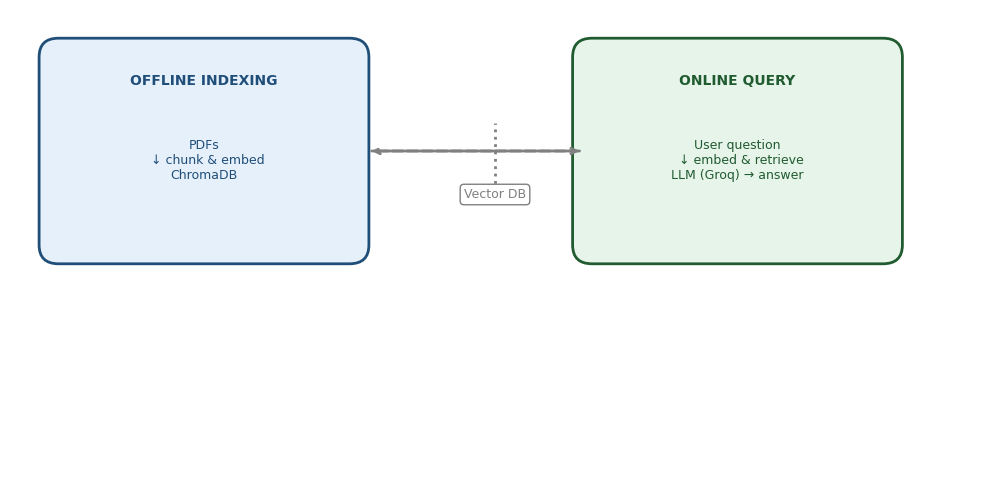

Architecture diagram saved as architecture.png


In [10]:
# Cell 9 — Architecture diagram (saved as architecture.png)
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 5)
ax.axis("off")

# Boxes
offline_box = mpatches.FancyBboxPatch((0.5, 2.5), 3, 2, boxstyle="round,pad=0.2",
                                      facecolor="#E6F0FA", edgecolor="#1F4E79", linewidth=2)
online_box = mpatches.FancyBboxPatch((6, 2.5), 3, 2, boxstyle="round,pad=0.2",
                                      facecolor="#E6F4EA", edgecolor="#215B30", linewidth=2)
ax.add_patch(offline_box)
ax.add_patch(online_box)

# Arrows
ax.annotate("", xy=(5.9, 3.5), xytext=(3.7, 3.5),
            arrowprops=dict(arrowstyle="->", color="gray", lw=2))
ax.annotate("", xy=(3.7, 3.5), xytext=(5.9, 3.5),
            arrowprops=dict(arrowstyle="->", color="gray", lw=2, linestyle="dashed"))

# Offline labels
ax.text(2, 4.2, "OFFLINE INDEXING", ha="center", fontweight="bold", color="#1F4E79")
ax.text(2, 3.2, "PDFs\n  ↓ chunk & embed\nChromaDB", ha="center", fontsize=9, color="#1F4E79")

# Online labels
ax.text(7.5, 4.2, "ONLINE QUERY", ha="center", fontweight="bold", color="#215B30")
ax.text(7.5, 3.2, "User question\n  ↓ embed & retrieve\nLLM (Groq) → answer", ha="center", fontsize=9, color="#215B30")

# Central storage icon
ax.plot([5, 5], [3.0, 3.8], color="gray", lw=2, linestyle="dotted")
ax.text(5, 3.0, "Vector DB", ha="center", fontsize=9, color="gray",
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray"))

plt.tight_layout()
plt.savefig("architecture.png", dpi=200, bbox_inches="tight")
plt.show()
print("Architecture diagram saved as architecture.png")